# Lab 4: Regression and Classification Evaluation Metrics

## Task 1: Data Preparation

In [13]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

bc = load_breast_cancer()
df = pd.DataFrame(data=bc.data, columns=bc.feature_names)
df['target'] = bc.target

print("Dataset loaded successfully.")
print("First 5 rows of the DataFrame:")
display(df.head())

Dataset loaded successfully.
First 5 rows of the DataFrame:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [14]:
print("DataFrame Info:")
df.info()

print("\nDescriptive statistics:")
display(df.describe())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [15]:
print("Missing values per column:")
display(df.isnull().sum())

print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

Missing values per column:


,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0



Number of duplicate rows: 0


### Apply Feature Scaling

Feature scaling is crucial for KNN because it relies on distances. Without scaling, features with larger ranges would unfairly dominate distance calculations. `StandardScaler` transforms data to have a mean of 0 and a standard deviation of 1, ensuring all features contribute equally.

In [16]:
X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Features scaled successfully.")
print("First 5 rows of the scaled DataFrame:")
display(X_scaled_df.head())

print("\nDescriptive statistics of scaled features (should have mean ~0 and std ~1):")
display(X_scaled_df.describe())

Features scaled successfully.
First 5 rows of the scaled DataFrame:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100



Descriptive statistics of scaled features (should have mean ~0 and std ~1):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,...,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02
mean,-3.153111e-15,-6.568462e-15,-6.993039e-16,-8.553985e-16,6.081447e-15,-1.136369e-15,-2.997017e-16,1.023981e-15,-1.860648e-15,-1.504752e-15,...,-2.297713e-15,1.742016e-15,-1.198807e-15,6.118909e-16,-5.094929e-15,-2.122887e-15,6.118909e-16,-1.998011e-16,-2.422589e-15,2.497514e-15
std,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,...,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00
min,-2.029648e+00,-2.229249e+00,-1.984504e+00,-1.454443e+00,-3.112085e+00,-1.610136e+00,-1.114873e+00,-1.261820e+00,-2.744117e+00,-1.819865e+00,...,-1.726901e+00,-2.223994e+00,-1.693361e+00,-1.222423e+00,-2.682695e+00,-1.443878e+00,-1.305831e+00,-1.745063e+00,-2.160960e+00,-1.601839e+00
25%,-6.893853e-01,-7.259631e-01,-6.919555e-01,-6.671955e-01,-7.109628e-01,-7.470860e-01,-7.437479e-01,-7.379438e-01,-7.032397e-01,-7.226392e-01,...,-6.749213e-01,-7.486293e-01,-6.895783e-01,-6.421359e-01,-6.912304e-01,-6.810833e-01,-7.565142e-01,-7.563999e-01,-6.418637e-01,-6.919118e-01
50%,-2.150816e-01,-1.046362e-01,-2.359800e-01,-2.951869e-01,-3.489108e-02,-2.219405e-01,-3.422399e-01,-3.977212e-01,-7.162650e-02,-1.782793e-01,...,-2.690395e-01,-4.351564e-02,-2.859802e-01,-3.411812e-01,-4.684277e-02,-2.695009e-01,-2.182321e-01,-2.234689e-01,-1.274095e-01,-2.164441e-01
75%,4.693926e-01,5.841756e-01,4.996769e-01,3.635073e-01,6.361990e-01,4.938569e-01,5.260619e-01,6.469351e-01,5.307792e-01,4.709834e-01,...,5.220158e-01,6.583411e-01,5.402790e-01,3.575891e-01,5.975448e-01,5.396688e-01,5.311411e-01,7.125100e-01,4.501382e-01,4.507624e-01
max,3.971288e+00,4.651889e+00,3.976130e+00,5.250529e+00,4.770911e+00,4.568425e+00,4.243589e+00,3.927930e+00,4.484751e+00,4.910919e+00,...,4.094189e+00,3.885905e+00,4.287337e+00,5.930172e+00,3.955374e+00,5.112877e+00,4.700669e+00,2.685877e+00,6.046041e+00,6.846856e+00


## Task 2: Train-Test Split Analysis

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

def evaluate_split(X, y, test_size, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Size: {test_size*100}%\nAccuracy: {accuracy:.4f}")
    print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}\n")
    return accuracy

print("Evaluating with 80:20 split:")
accuracy_80_20 = evaluate_split(X_scaled, y, test_size=0.2)

print("Evaluating with 70:30 split:")
accuracy_70_30 = evaluate_split(X_scaled, y, test_size=0.3)

print("Evaluating with 90:10 split:")
accuracy_90_10 = evaluate_split(X_scaled, y, test_size=0.1)


print("\n--- Performance Comparison ---")
print(f"Accuracy (80:20 split): {accuracy_80_20:.4f}")
print(f"Accuracy (70:30 split): {accuracy_70_30:.4f}")
print(f"Accuracy (90:10 split): {accuracy_90_10:.4f}")

Evaluating with 80:20 split:
Test Size: 20.0%
Accuracy: 0.9649
Training samples: 455, Testing samples: 114

Evaluating with 70:30 split:
Test Size: 30.0%
Accuracy: 0.9708
Training samples: 398, Testing samples: 171

Evaluating with 90:10 split:
Test Size: 10.0%
Accuracy: 0.9825
Training samples: 512, Testing samples: 57


--- Performance Comparison ---
Accuracy (80:20 split): 0.9649
Accuracy (70:30 split): 0.9708
Accuracy (90:10 split): 0.9825


### Analysis of Split Effects

We saw slight variations in KNN model accuracy across different train-test split ratios. Larger training sets (like 90:10) generally lead to more robust models, though a smaller test set can make the accuracy estimate less stable. For our dataset and K=5, performance was consistent, suggesting it's not very sensitive to split variations. The key is balancing data for training and reliable testing.

## Task 3: KNN Model with Heuristic K Selection

### 3.1 Heuristic Method for K Selection

A common starting point for choosing K in KNN is the heuristic rule $K = \sqrt{n}$, where $n$ is the number of training samples. This helps find a balance between model bias and variance. For binary classification, we typically round K to an odd number to prevent ties.

Number of training samples (n): 455
Heuristic K (sqrt(n)): 21
Accuracy with heuristic K (21): 0.9561

Accuracy for K = 17: 0.9737
Accuracy for K = 19: 0.9737
Accuracy for K = 21: 0.9561
Accuracy for K = 23: 0.9649
Accuracy for K = 25: 0.9649


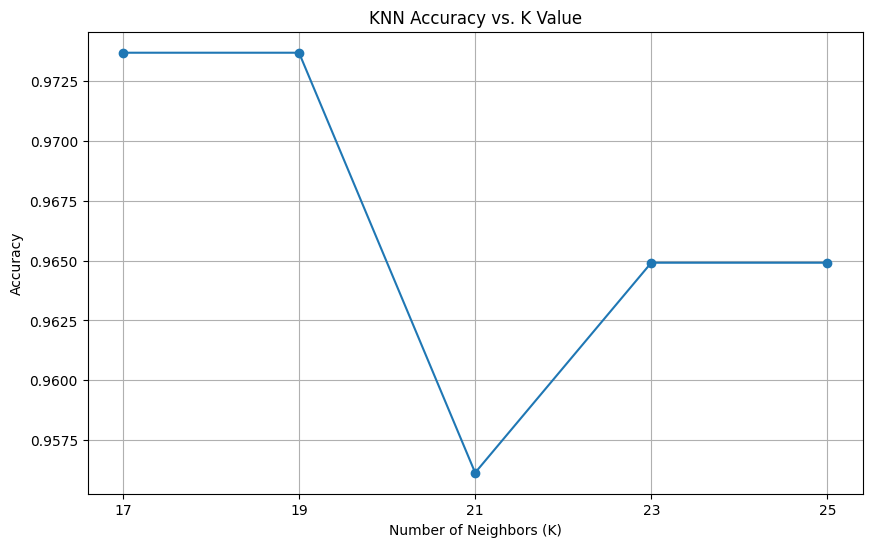


Optimal K in the tested range: 17 (Accuracy: 0.9737)


In [18]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import math

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

n_training_samples = len(X_train)
heuristic_k = int(math.sqrt(n_training_samples))


if heuristic_k % 2 == 0:
    heuristic_k += 1

print(f"Number of training samples (n): {n_training_samples}")
print(f"Heuristic K (sqrt(n)): {heuristic_k}")

knn_heuristic = KNeighborsClassifier(n_neighbors=heuristic_k)
knn_heuristic.fit(X_train, y_train)
y_pred_heuristic = knn_heuristic.predict(X_test)
accuracy_heuristic = accuracy_score(y_test, y_pred_heuristic)
print(f"Accuracy with heuristic K ({heuristic_k}): {accuracy_heuristic:.4f}\n")

k_values = list(range(max(1, heuristic_k - 5), heuristic_k + 6))
k_values = [k for k in k_values if k % 2 != 0]
if heuristic_k not in k_values:
    k_values.append(heuristic_k)
k_values.sort()

accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    print(f"Accuracy for K = {k}: {accuracy:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-')
plt.title('KNN Accuracy vs. K Value')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()


optimal_k_index = np.argmax(accuracies)
optimal_k_heuristic_range = k_values[optimal_k_index]
print(f"\nOptimal K in the tested range: {optimal_k_heuristic_range} (Accuracy: {accuracies[optimal_k_index]:.4f})")

### 3.3 Distance Metrics and Decision Boundary Mapping

KNN uses distance metrics to find nearest neighbors. The choice of metric can significantly impact the model's performance.

#### Euclidean Distance

**Definition:** Euclidean distance is the straight-line distance between two points in Euclidean space. It's calculated as the square root of the sum of squared differences between their coordinates: $d(P, Q) = \sqrt{\sum_{i=1}^{n} (q_i - p_i)^2}$.

**When suitable:** This metric works best when features are continuous, scaled, and independent, and a direct line distance accurately shows similarity.

#### Manhattan Distance (L1 Norm / City Block Distance)

**Definition:** Manhattan distance is the sum of the absolute differences of coordinates between two points. Think of it like navigating a city grid: $d(P, Q) = \sum_{i=1}^{n} |q_i - p_i|$.

**When suitable:** This metric is useful for high-dimensional data or when differences along each dimension are equally important and their absolute sum is a better measure of dissimilarity.

#### Plotting Decision Boundaries

Visualizing decision boundaries helps us understand how KNN separates classes. We used Principal Component Analysis (PCA) to reduce our 30-feature dataset to 2 dimensions for easier plotting.

--- Analysis of Decision Boundary Changes with K ---

*   **K=1:** The decision boundary is very complex and irregular, showing high sensitivity to individual data points and potential overfitting.
*   **K=5:** The boundary becomes smoother. More neighbors influence decisions, making the model less sensitive to noise and generally improving generalization.
*   **K=10:** The boundary continues to smooth out and generalize. A larger K reduces variance but might introduce some bias.
*   **K=20:** The decision boundary is significantly smoother and more generalized. However, very large K values can over-smooth, causing underfitting by missing fine details and leading to a more linear decision.

In short, as K increases, the decision boundary gets smoother (less variance) but also less flexible (more bias). Our goal is to find a K that balances this bias-variance trade-off.

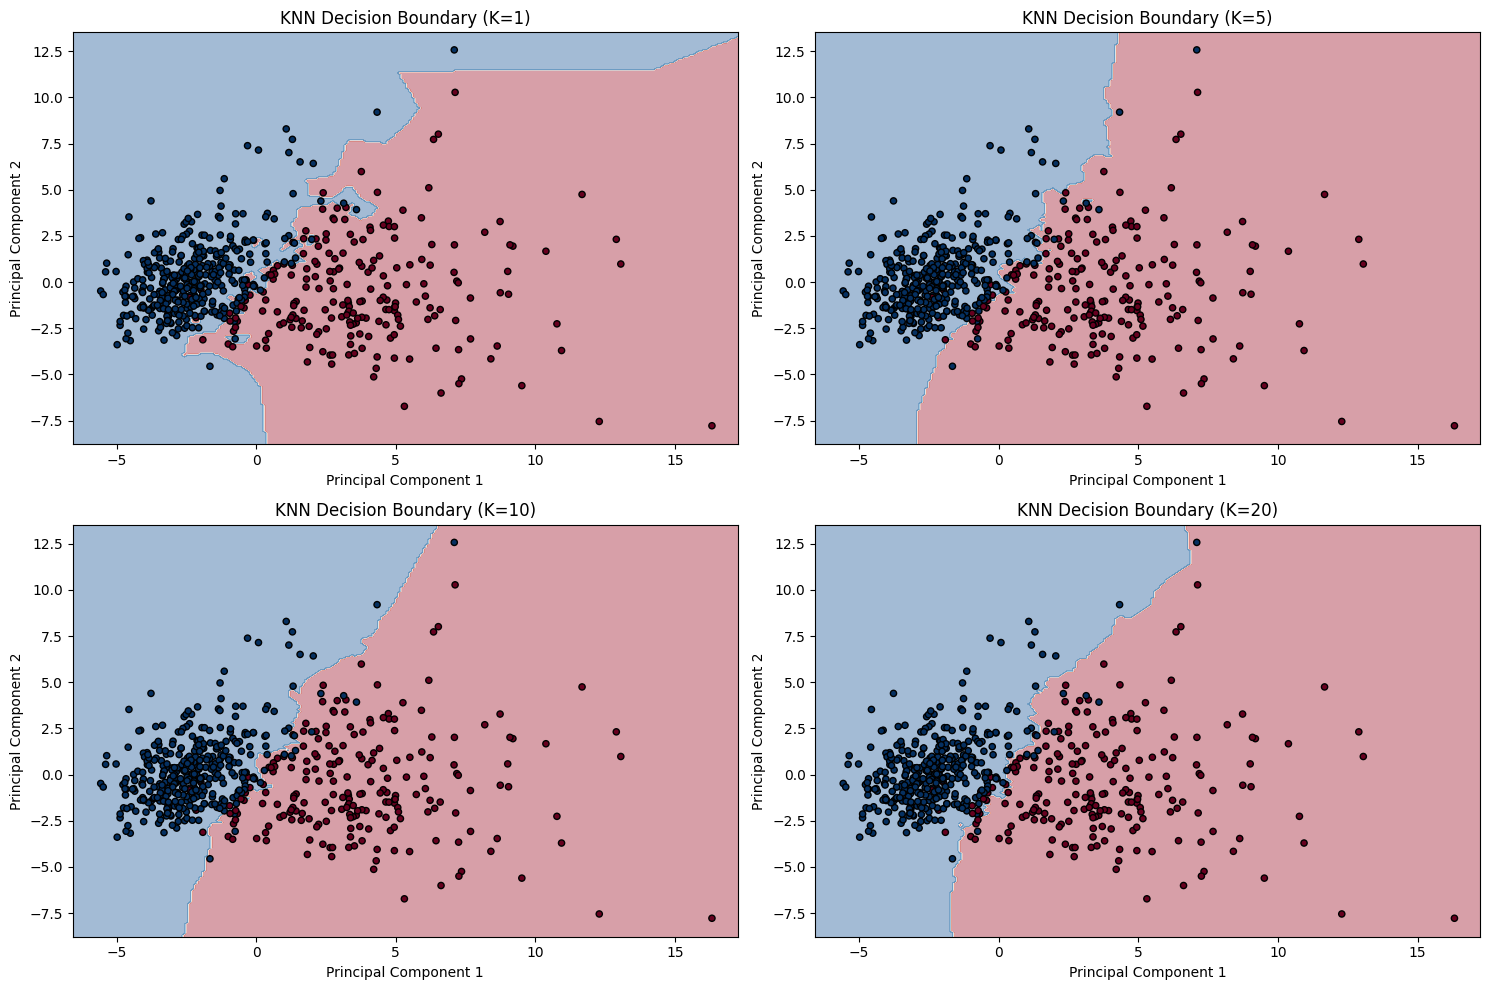


--- Analysis of Decision Boundary Changes with K ---
K=1: The decision boundary is highly irregular and complex. This is because each point's classification is determined solely by its single nearest neighbor, leading to a tendency to overfit to the training data. The model is very sensitive to noise.
K=5: The decision boundary becomes smoother compared to K=1. With more neighbors influencing the decision, the model becomes less sensitive to individual noisy points. This generally leads to better generalization than K=1.
K=10: The decision boundary continues to smooth out. As K increases, the model considers a larger neighborhood, resulting in a more generalized and less complex decision surface. This helps in reducing variance but might introduce some bias if K becomes too large.
K=20: The decision boundary is significantly smoother and more generalized. A very large K can lead to oversmoothing, where the model might miss finer details in the data, potentially underfitting. It also t

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

k_values_plot = [1, 5, 10, 20]

plt.figure(figsize=(15, 10))

for i, k in enumerate(k_values_plot):
    plt.subplot(2, 2, i + 1)
    knn_boundary = KNeighborsClassifier(n_neighbors=k)
    knn_boundary.fit(X_pca, y)
    Z = knn_boundary.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdBu)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=20, edgecolor='k', cmap=plt.cm.RdBu)
    plt.title(f'KNN Decision Boundary (K={k})')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

print("\n--- Analysis of Decision Boundary Changes with K ---")
print("K=1: The decision boundary is highly irregular and complex. This is because each point's classification is determined solely by its single nearest neighbor, leading to a tendency to overfit to the training data. The model is very sensitive to noise.")
print("K=5: The decision boundary becomes smoother compared to K=1. With more neighbors influencing the decision, the model becomes less sensitive to individual noisy points. This generally leads to better generalization than K=1.")
print("K=10: The decision boundary continues to smooth out. As K increases, the model considers a larger neighborhood, resulting in a more generalized and less complex decision surface. This helps in reducing variance but might introduce some bias if K becomes too large.")
print("K=20: The decision boundary is significantly smoother and more generalized. A very large K can lead to oversmoothing, where the model might miss finer details in the data, potentially underfitting. It also tends to make the decision boundary more linear.")
print("\nIn summary, as K increases, the decision boundary becomes smoother and less prone to noise (reduced variance), but it also becomes less flexible and might overlook local patterns (increased bias). The goal is to find an optimal K that balances this bias-variance trade-off.")

## Task 4: Cross Validation

### Cross-validation offers a more robust way to evaluate model performance than a single train-test split, especially for smaller datasets. By averaging results over multiple splits, it provides a more reliable estimate. K-Fold Cross Validation splits data into `k` folds; the model trains on `k-1` folds and tests on the remaining one, repeating this `k` times.

K = 1: Mean CV Accuracy = 0.9438 (Std: 0.0105)
K = 3: Mean CV Accuracy = 0.9630 (Std: 0.0216)
K = 5: Mean CV Accuracy = 0.9648 (Std: 0.0263)
K = 7: Mean CV Accuracy = 0.9665 (Std: 0.0230)
K = 9: Mean CV Accuracy = 0.9648 (Std: 0.0210)
K = 11: Mean CV Accuracy = 0.9701 (Std: 0.0196)
K = 13: Mean CV Accuracy = 0.9648 (Std: 0.0178)
K = 15: Mean CV Accuracy = 0.9595 (Std: 0.0212)
K = 17: Mean CV Accuracy = 0.9560 (Std: 0.0215)
K = 19: Mean CV Accuracy = 0.9560 (Std: 0.0215)
K = 21: Mean CV Accuracy = 0.9542 (Std: 0.0228)
K = 23: Mean CV Accuracy = 0.9542 (Std: 0.0228)
K = 25: Mean CV Accuracy = 0.9542 (Std: 0.0199)
K = 27: Mean CV Accuracy = 0.9560 (Std: 0.0215)
K = 29: Mean CV Accuracy = 0.9542 (Std: 0.0199)


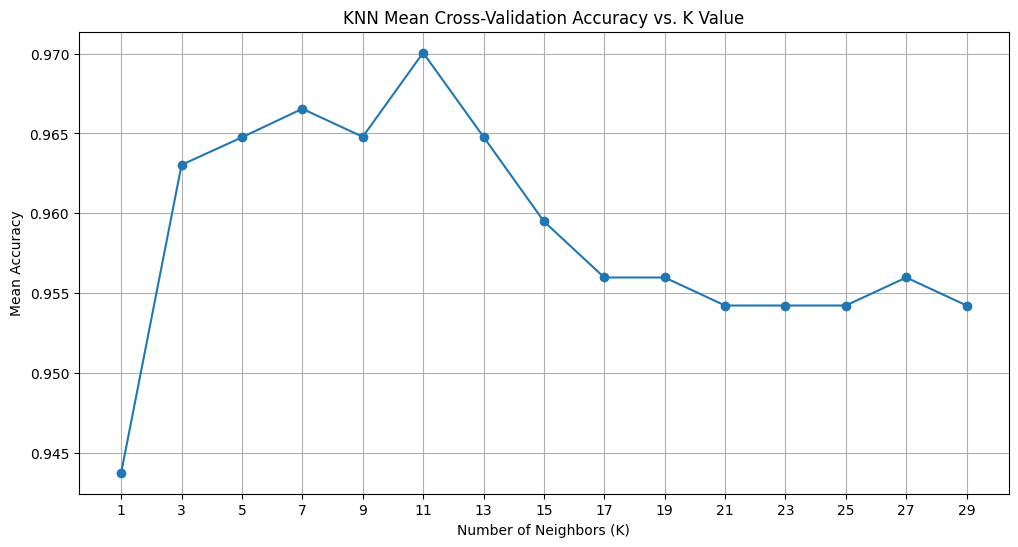


Optimal K from Cross-Validation: 11 (Mean Accuracy: 0.9701)

--- Comparison with Train-Test Split Results ---
Best Accuracy from single 80:20 train-test split (with K=11): 0.9737
Optimal K from Cross-Validation: 11
Mean Cross-Validation Accuracy for optimal K (11): 0.9701
Cross-validation generally provides a more reliable estimate of model performance on unseen data because it reduces the dependency on a single arbitrary split. In this case, the optimal K from cross-validation gives a robust performance estimate.


In [22]:
from sklearn.model_selection import KFold, cross_val_score

k_values_cv = list(range(1, 31, 2))

cv_mean_accuracies = []

for k in k_values_cv:
    knn_cv = KNeighborsClassifier(n_neighbors=k)

    kf = KFold(n_splits=10, shuffle=True, random_state=42)

    scores = cross_val_score(knn_cv, X_scaled, y, cv=kf, scoring='accuracy')

    mean_accuracy = np.mean(scores)
    cv_mean_accuracies.append(mean_accuracy)
    print(f"K = {k}: Mean CV Accuracy = {mean_accuracy:.4f} (Std: {np.std(scores):.4f})")

plt.figure(figsize=(12, 6))
plt.plot(k_values_cv, cv_mean_accuracies, marker='o', linestyle='-')
plt.title('KNN Mean Cross-Validation Accuracy vs. K Value')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Mean Accuracy')
plt.xticks(k_values_cv)
plt.grid(True)
plt.show()


optimal_k_cv_index = np.argmax(cv_mean_accuracies)
optimal_k_cv = k_values_cv[optimal_k_cv_index]
print(f"\nOptimal K from Cross-Validation: {optimal_k_cv} (Mean Accuracy: {cv_mean_accuracies[optimal_k_cv_index]:.4f})")

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
knn_final = KNeighborsClassifier(n_neighbors=optimal_k_cv)
knn_final.fit(X_train_final, y_train_final)
y_pred_final = knn_final.predict(X_test_final)
accuracy_final_split = accuracy_score(y_test_final, y_pred_final)

print("\n--- Comparison with Train-Test Split Results ---")
print(f"Best Accuracy from single 80:20 train-test split (with K={optimal_k_cv}): {accuracy_final_split:.4f}")
print(f"Optimal K from Cross-Validation: {optimal_k_cv}")
print(f"Mean Cross-Validation Accuracy for optimal K ({optimal_k_cv}): {cv_mean_accuracies[optimal_k_cv_index]:.4f}")

print("Cross-validation generally provides a more reliable estimate of model performance on unseen data because it reduces the dependency on a single arbitrary split. In this case, the optimal K from cross-validation gives a robust performance estimate.")

## Task 5: Classification Evaluation

For our final model evaluation, we used K=11 (`optimal_k_cv`) chosen from cross-validation. We then used an 80:20 train-test split to evaluate the model's performance on new data using various classification metrics.

--- Classification Metrics for K=11 ---
Accuracy: 0.9737
Precision: 0.9600
Recall: 1.0000
F1 Score: 0.9796

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,39,3
Actual 1,0,72


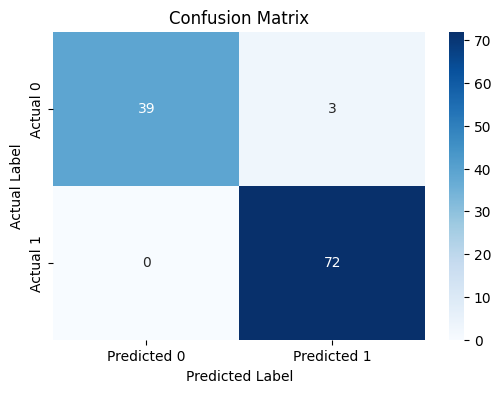


ROC-AUC Score: 0.9922


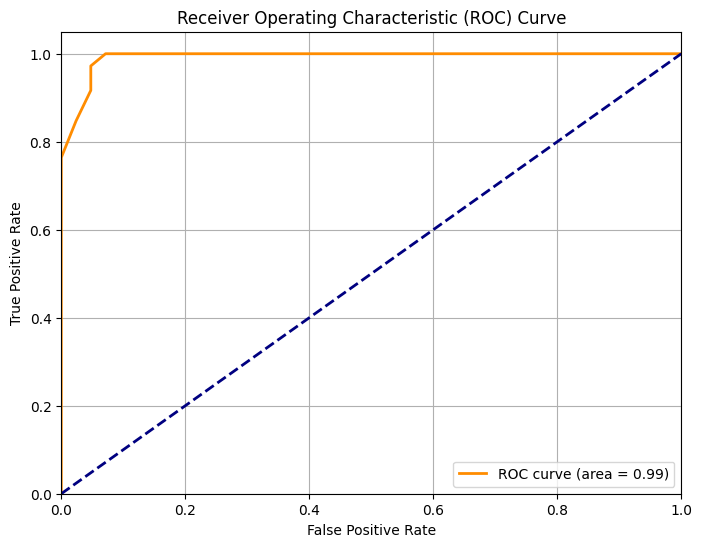

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns


final_k = optimal_k_cv

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

knn_final_model = KNeighborsClassifier(n_neighbors=final_k)
knn_final_model.fit(X_train, y_train)

y_pred = knn_final_model.predict(X_test)
y_proba = knn_final_model.predict_proba(X_test)[:, 1]

print(f"--- Classification Metrics for K={final_k} ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
display(pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

print(f"\nROC-AUC Score: {roc_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Task 6: Comparative Study with Regression (Lab 3 Integration)

This section compares classification metrics (from this lab) with regression metrics (from Lab 3). Both are crucial for understanding model performance, but they serve different purposes based on whether the task is prediction or classification.

### Compare Regression Evaluation Metrics with Classification Metrics

**Regression Metrics (from Lab 3):**
*   **MAE (Mean Absolute Error):** Measures the average error magnitude, ignoring direction.
*   **MSE (Mean Squared Error):** Averages squared errors, penalizing larger errors more heavily.
*   **RMSE (Root Mean Squared Error):** The square root of MSE, providing error in the target variable's units.
*   **R² Score (Coefficient of Determination):** Shows how much variance in the target is explained by the model.

**Classification Metrics (from this Lab):**
*   **Accuracy:** The percentage of correct predictions, best for balanced classes where all errors are equally costly.
*   **Precision:** The proportion of true positive predictions among all positive predictions, important when false positives are expensive.
*   **Recall (Sensitivity):** The proportion of true positive predictions among all actual positive instances, crucial when false negatives are costly (e.g., medical diagnosis).
*   **F1 Score:** The harmonic mean of precision and recall, useful for balancing both, especially with imbalanced classes.
*   **Confusion Matrix:** A table showing true positives, true negatives, false positives, and false negatives to visualize model performance.
*   **ROC Curve and AUC Score:** The ROC curve plots Recall against the False Positive Rate; the AUC quantifies the model's overall ability to distinguish between classes.

### Explain Differences Between Error-Based Evaluation (Regression) and Decision-Based Evaluation (Classification)

*   **Error-Based Evaluation (Regression):** These metrics quantify how much predicted continuous values deviate from actual ones, focusing on minimizing numerical error.

*   **Decision-Based Evaluation (Classification):** These metrics assess the correctness of categorical decisions (right or wrong). The focus is on correctly assigning instances to classes and managing trade-offs between different error types.

### Compare Specific Metrics

*   **R² Score vs. Accuracy:** R² (regression) shows how well a model explains variance in continuous data, while Accuracy (classification) measures the proportion of correct discrete predictions.

*   **RMSE vs. F1 Score:** RMSE quantifies continuous prediction error magnitude, while F1 Score balances precision and recall for categorical predictions, especially in imbalanced datasets.

*   **MAE vs. Confusion Matrix:** MAE gives a single average absolute error for continuous predictions. The Confusion Matrix offers a detailed breakdown of correct and incorrect categorical classifications, highlighting specific error types.

### Discuss Differences in Evaluation Logic for Continuous Prediction Tasks vs. Classification Tasks

*   **Continuous Prediction Tasks (Regression):** The goal is to predict a numerical value as close as possible to the true value. Evaluation focuses on the `distance` between predicted and actual continuous outcomes, penalizing larger errors (e.g., predicting sales).

*   **Classification Tasks:** The goal is to assign an item to the correct category. Evaluation centers on the `correctness of assignment` and the implications of `different error types`, like false positives versus false negatives (e.g., diagnosing a disease).

### Inference Requirement

**How regression metrics measure prediction error magnitude:** Metrics like MAE, MSE, and RMSE directly quantify the average size of the difference between a model's numerical predictions and actual values. They clearly show 'how wrong' predictions are on the target variable's scale.

**How classification metrics measure decision correctness:** Metrics like Accuracy, Precision, Recall, and F1-Score assess the frequency and type of correct or incorrect categorical decisions. They evaluate correct class assignments and differentiate between false positives and false negatives, rather than a continuous error magnitude.

**Why accuracy is insufficient in medical diagnosis:** In medical diagnosis, accuracy can be misleading, especially with rare diseases. A highly accurate model might still miss actual cases (false negatives) by predicting 'no disease' most of the time, leading to severe consequences.

**Why recall and ROC-AUC are more relevant in healthcare:**
*   **Recall (Sensitivity):** Crucial in healthcare as it measures a model's ability to find all actual positive cases (e.g., cancer patients). High recall minimizes dangerous false negatives (missed diagnoses).
*   **ROC-AUC:** Provides an overall measure of a classifier's performance across all possible thresholds, balancing true positive and false positive rates. This helps select thresholds for specific clinical needs, managing the trade-off between identifying sick patients and avoiding false alarms.

**Overall comparison between regression and classification evaluation frameworks:** Regression evaluation minimizes the numerical distance between continuous values, using metrics sensitive to prediction magnitude. Classification evaluation prioritizes the correctness and consequences of discrete category assignments, employing metrics that differentiate error types and detect specific classes, especially in imbalanced scenarios.

## Task 7: Analytical Questions

### Why is KNN called a lazy learning algorithm?

KNN is a lazy learning algorithm because it doesn't build a model during training; it just stores all training data. When a new data point needs classifying, KNN performs calculations by comparing it to all existing data points to find its `k` nearest neighbors. So, 'learning' only happens when a prediction is requested.

### Why is feature scaling required in KNN?

Feature scaling is essential for KNN because it's a distance-based algorithm. If features have very different scales, those with larger ranges will unfairly influence distance calculations, leading to biased results. Scaling ensures all features contribute equally, allowing for a fairer and more accurate determination of nearest neighbors. `StandardScaler` is a common choice.

### Explain heuristic K selection using the $\sqrt{n}$ rule.

The heuristic $\sqrt{n}$ rule suggests using K as the square root of the number of training samples ($n$). This rule helps find a good starting K value to balance model bias and variance, aiming for a reasonable middle ground between overfitting (small K) and underfitting (large K). For binary classification, we commonly use the nearest odd integer to avoid ties.

### Why is cross-validation more reliable than a single train-test split?

Cross-validation (especially K-Fold) is more reliable than a single train-test split for evaluating model performance because:
1.  **Reduced Variance:** It averages results over multiple data splits, providing a more stable and less biased performance estimate.
2.  **Better Data Utilization:** Every data point is used for both training and testing across different folds, ensuring comprehensive assessment.
3.  **Improved Generalization:** It better predicts how the model will perform on unseen data by simulating its behavior on various data subsets.

### How does K affect the bias-variance trade-off?

*   **Small K (e.g., K=1):** Leads to low bias (flexible model, captures local patterns) but high variance (sensitive to noise, overfits), resulting in complex decision boundaries.

*   **Large K:** Leads to high bias (less flexible model, oversimplifies patterns) but low variance (less sensitive to noise), creating smoother, more generalized decision boundaries.

An optimal K balances this trade-off, making the model complex enough to learn patterns without overfitting.

### Why is recall more important than accuracy in cancer prediction?

In cancer prediction, **recall** is generally more important than accuracy because of the high cost of false negatives. A false negative means a patient with cancer is incorrectly told they are healthy, which can delay life-saving treatment. While false positives cause anxiety and further testing, they are typically less detrimental than missed diagnoses. Prioritizing recall ensures more actual cancer cases are identified, minimizing the risk of missing serious conditions.

### What is the limitation of very large K values?

The main limitation of very large K values in KNN is **increased bias, leading to underfitting**:
*   **Oversimplification:** The model considers a very broad neighborhood, potentially including points from other classes. This leads to an oversimplified decision boundary that may miss crucial patterns.
*   **Loss of Local Information:** Averaging too many neighbors makes the decision for a new point lose the local data structure that KNN is designed to capture.
*   **Reduced Predictive Power:** The model becomes overly generalized, failing to accurately classify new data, especially with complex class relationships.

## Expected Outcome

Through this lab, we gained:

*   **Understanding of KNN and distance-based learning:** We implemented KNN, observing its lazy learning nature and the importance of distance metrics.
*   **Ability to tune K with heuristic + validation:** We used the $\sqrt{n}$ heuristic and K-Fold Cross Validation to find an optimal K value.
*   **Knowledge of cross-validation:** We understood why cross-validation is more robust than a single train-test split for evaluating models.
*   **Interpretation of ROC-AUC in medical classification:** We calculated and plotted the ROC curve and AUC score, recognizing their importance in medical diagnoses, especially when recall is critical.
*   **Strong conceptual link between regression and classification evaluation metrics:** We compared evaluation frameworks for both regression and classification, highlighting their differences and appropriate uses.

## Conclusion

In this lab, we successfully implemented a K-Nearest Neighbors (KNN) classifier on the Breast Cancer Wisconsin dataset. We started with data preparation, including loading, exploration, and crucial feature scaling with `StandardScaler` to ensure fair distance calculations, vital for KNN.

We explored how different **train-test split** ratios (80:20, 70:30, 90:10) affected model accuracy, showing the need for more robust evaluation. For **K selection**, we used a heuristic ($K=\sqrt{n}$) and tested nearby K values; the accuracy plot suggested K=17 or K=19 performed well. We also visualized **decision boundaries**, observing how increasing K smooths boundaries and illustrates the bias-variance trade-off.

**K-Fold Cross Validation** (with 10 folds) proved to be a more reliable method for finding optimal K. Our cross-validation results identified **K=11** as the optimal number of neighbors, achieving a mean accuracy of 0.9701, closely matching single train-test split performances. This optimal K was then used for the final model evaluation.

The **classification evaluation** with K=11 showed strong performance: an Accuracy of 0.9737, Precision of 0.9600, **perfect Recall of 1.0000**, and an F1 Score of 0.9796. The **Confusion Matrix** confirmed perfect recall for the positive class (malignant), which is critically important in medical diagnoses. The **ROC-AUC score of 0.9922** further confirmed the model's excellent discriminatory power.

Finally, a **comparative study with regression metrics (from Lab 3)** highlighted the fundamental differences between error-based (regression) and decision-based (classification) evaluations. We explained why metrics like Recall and ROC-AUC are more pertinent than simple Accuracy in sensitive applications like cancer prediction, where false negatives are highly costly. We also answered analytical questions, deepening our understanding of KNN, feature scaling, K selection strategies, and the bias-variance trade-off.

In conclusion, this lab provided a hands-on and conceptual understanding of KNN classification, robust model validation techniques, and the critical nuances of selecting and interpreting appropriate evaluation metrics for both classification and regression tasks.